In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score,average_precision_score,confusion_matrix,roc_curve,ConfusionMatrixDisplay,RocCurveDisplay,balanced_accuracy_score
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [160]:
subject_info = pd.read_csv('/Users/eric/repos/aud/data/subject_info.csv')
included_subids = subject_info.query("responsiveness>=0.25").subid.unique()
print(len(included_subids))
subject_info.head()

148


,subid,mema_count,last_morning_ema_day,first_morning_ema_day,responsiveness
0,1,64,89,0,0.711111
1,2,77,84,0,0.905882
2,3,87,89,0,0.966667
3,5,90,91,0,0.988889
4,6,79,86,0,0.908046


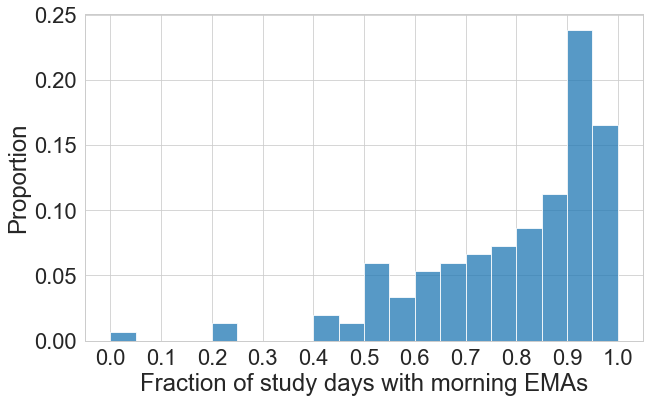

In [7]:
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2.5)
subinfo = subject_info.copy(deep=True)
subinfo.mema_count = subinfo.apply(lambda row: 90 if row.mema_count>90 else row.mema_count,axis=1)
fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(data=subinfo,x='responsiveness',ax=ax,stat='proportion',binwidth=0.05,binrange=(0,1))
ax.set_xticks(np.arange(0,1.1,.1))
ax.set_xlabel('Fraction of study days with morning EMAs')
fig.savefig("plots/ema_missingness.pdf",bbox_inches='tight',facecolor='w')

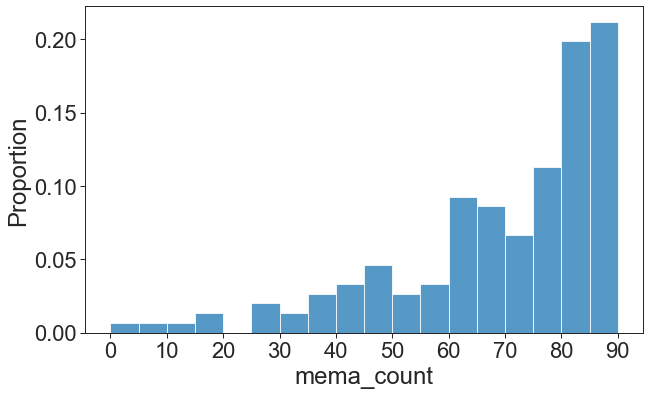

In [31]:
sns.set_style('ticks')
sns.set_context('paper',font_scale=2.5)
labels = pd.read_csv('/Users/eric/repos/aud/data/ml_labels.csv')
labels.head()
output_list = []
for window in [0,1,3,7]:
    label_str = 'lapse_w'+str(window)
    lapse_labels = labels[label_str].dropna().to_numpy().sum()
    total_count = labels[label_str].dropna().shape[0]
    temp_df = pd.DataFrame({"window":window,"fraction":lapse_labels/total_count},index=[0])
    output_list.append(temp_df)

outputs = pd.concat(output_list,ignore_index=True)

subinfo.mema_count = subinfo.apply(lambda row: 90 if row.mema_count>90 else row.mema_count,axis=1)
fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(data=subinfo,x='mema_count',ax=ax,stat='proportion',bins=np.arange(0,95,5))
ax.set_xticks(np.arange(0,100,10))

#fig.savefig("plots/lapse_proportions.pdf",bbox_inches='tight',facecolor='w')

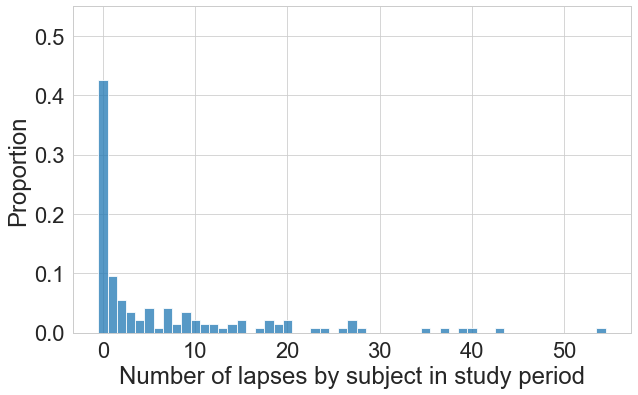

In [6]:
sns.set_context('paper',font_scale=2.5)
day_labels = pd.read_csv('/Users/eric/repos/aud/data/day_labels.csv')
day_labels.head()
lapse_sums = day_labels.query("subid in @included_subids").groupby("subid").lapse.sum()
lapse_sums.head()
fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(x=lapse_sums,ax=ax,stat='proportion',discrete=True)
ax.set_xlabel("Number of lapses by subject in study period")
ax.set_yticks(np.arange(0,0.6,0.1))
ax.set_ylim((0,0.55))
fig.savefig("plots/lapse_proportions.pdf",bbox_inches='tight',facecolor='w')

In [8]:
# 164409 is complete dataset with clipping occurring before averaging
# 175905 runs MLE, MARSS (with longer runs), MAP_mle, and MAP_marss
# 1571875 runs MLE, MAP_mle with bugfix to prior creation script (subject 137 errored out previously) and with bounds on d (numerous errors, data unusable)
# 1578700 runs MLE, MAP_mle with projected evaluations (frozen parameter models) at a limited set of timesteps
# 1579231 runs MLE, MAP_mle with frozen parameter models at the complete timestep range
# 1583624 runs MLE, MAP_mle with updated label files and fixed map_fitter
import_path = "/Users/eric/repos/aud/analysis/imports/1583624"
frozen=False
files = [file for file in os.listdir(import_path) if file.endswith(".csv")]
df_list = []
for file in files:
    iter_df = pd.read_csv(os.path.join(import_path,file))
    if iter_df.shape[1] != 23:
        pass#print("wtf")
    df_list.append(iter_df)

#print(len(df_list))
df = pd.concat(df_list,ignore_index=True)
print(df.shape)

# For previous case without frozen parameter projection
if frozen:
    ss_df = df[['subid','train_horizon','day','w0_pred','w0_act','w1_pred',
                 'w1_act','w3_pred','w3_act','w7_pred','w7_act','fit_type']]
else:
    ss_df = df[['subid','train_horizon',"day",'w0_pred','w0_act','w1_pred',
                 'w1_act','w3_pred','w3_act','w7_pred','w7_act','fit_type']].rename(mapper={'train_horizon':'study_day'},axis=1)

# Note that study day is 1 indexed and corresponds to the inclusive number of days since the study start (i.e. the first day there is an EMA would be day 1, the next day would be day 2, etc.)
ss_df.head()

(24850, 67)


,subid,study_day,day,w0_pred,w0_act,w1_pred,w1_act,w3_pred,w3_act,w7_pred,w7_act,fit_type
0,224,2,2,2.942349e-02,0,5.964507e-02,0.0,1.115515e-01,0.0,1.872270e-01,0.0,MAP_mle
1,224,3,3,1.760611e-02,0,1.810747e-02,0.0,1.823019e-02,0.0,1.823113e-02,0.0,MAP_mle
2,224,4,4,9.999779e-13,0,4.726882e-07,0.0,4.726902e-07,0.0,4.726942e-07,0.0,MAP_mle
3,224,5,5,6.679497e-02,0,1.275270e-01,0.0,2.328210e-01,0.0,4.030883e-01,0.0,MAP_mle
4,224,6,6,1.004405e-02,0,1.088132e-02,0.0,1.309604e-02,0.0,1.510666e-02,0.0,MAP_mle


In [57]:
ss_df[ss_df.study_day!=ss_df.day].subid.unique()

array([ 97, 178, 180, 166, 190,  77, 191,  76, 185,  66, 139,  74,  64,
       245,  79,  90])

In [11]:
# Sanity checks for data outside the subject's [first ema,last ema] range. If anything shows up here, it must be addressed.

for idx,row in subject_info.iterrows():
    subid = row.subid
    last_ema = row.last_morning_ema_day+1
    last_ema_adj = min(last_ema,90)
    first_ema = row.first_morning_ema_day+1
    sub_df = ss_df.query("subid==@subid").copy()
    if(any(sub_df.day>last_ema_adj)):
        print(subid,last_ema, "needs attention")
        idxs = sub_df[sub_df.day > (last_ema_adj)].index.to_numpy()
        print("Dropping {} rows".format(len(idxs)))
        ss_df.drop(labels=idxs,axis=0,inplace=True)
    if(any(sub_df.day < first_ema)):
        print("hey now")
        idxs = sub_df[sub_df.day < first_ema].index.to_numpy()
        print(subid,first_ema)
        display(sub_df.loc[idxs])
        #print(ss_df.shape)
        #ss_df.drop(labels=idxs,axis=0,inplace=True)
       #print(ss_df.shape)

74.0 88.0 needs attention
Dropping 2 rows


In [12]:
# 475750 is ML run with 100 iterations for XGB search
# 475789 is ML run with 500 iterations (and updated objective and hyperparameter grid)
# 475949 is ML run with same parameters as 789, but changed scoring to f1
# 479995 is ML run with similar parameters to previous runs, but using sklearn GBC rather than XGBoost
# 480141 is ML run with XGBoost again, but with modified ml_alt featurization
# 481249 is same as 480141 but with the hyperparameter tuning folds shuffled
# 483969 is similar to last run, but adds 10 fold parameter CV + class weighting to LR/XGB search gricd
# 489864 is similar to last run, but returns to 5 fold, smaller search space, more search itations, no LR weighting
# 530741 starts over with smaller search grid, no positive weighting, grid search, and neg_log_loss fitting for improved calibration
# 537411 is similar to previous, but with separate tuning grids for w0 and w1/3/7
# 541980 tries to resolve bug with w0 case
# 585836 is similar to above, but with 10 fold CV (only w0)
# 586778 is similar to above but with neg_log_loss (only w0)
# 587942 is similar to above but uses the alt grid for w0 (only w0)
# 589432 uses alt grid for all predictions (w0,1,3,7), keeping neg log loss and 10fold CV
# 595117 repeats previous case with f1 score for hyperparameter tuning
# # 1572467 repeats previous case with fix to original dataset to remove nan cases not tested by the SSMs
# 1580829 repeats previous case with modified hyperparameter grid, first in new format
# 1583623 is new run with updated labels file
# 1583704 is a test run with expanded training loop for ML
# 1585680 is the 20-fold group stratified CV with a larger parameter grid
run = 1585680
new_format = run>1572467
import_path = "/Users/eric/repos/aud/analysis/imports/"+str(run)

files = [file for file in os.listdir(import_path) if file.endswith(".csv")]
df_list = []
for file in files:
    iter_df = pd.read_csv(os.path.join(import_path,file))
    df_list.append(iter_df)

#print(len(df_list))
ml_df = pd.concat(df_list,ignore_index=True)
print(ml_df.shape)
# The ML fits are done on zero-indexed data, need to add 1 to get to 1 indexing
ml_df.day = ml_df.day+1
ml_df.train_horizon = ml_df.train_horizon+1


def ml_fit_study_day_adder(subid,day,subject_info):
    sub = subject_info.query("subid==@subid")
    first_ema = sub.iloc[0].first_morning_ema_day # note 0 indexed
    if first_ema == 0:
        return int(day)
    else:
        return int(day-first_ema)

ml_df['study_day'] = ml_df.apply(lambda row: ml_fit_study_day_adder(row.subid,row.day,subject_info),axis=1)
ml_df.head()
# if not(new_format):
#     ml_df.insert(loc=1, column = 'train_horizon',value = np.nan)
# ml_df.head()

if new_format:
    full_df = ss_df.reset_index(drop=True)
else:
    full_df = pd.concat([ss_df,ml_df],ignore_index=True)
full_df.head()

(98078, 7)


,subid,study_day,day,w0_pred,w0_act,w1_pred,w1_act,w3_pred,w3_act,w7_pred,w7_act,fit_type
0,224,2,2,2.942349e-02,0,5.964507e-02,0.0,1.115515e-01,0.0,1.872270e-01,0.0,MAP_mle
1,224,3,3,1.760611e-02,0,1.810747e-02,0.0,1.823019e-02,0.0,1.823113e-02,0.0,MAP_mle
2,224,4,4,9.999779e-13,0,4.726882e-07,0.0,4.726902e-07,0.0,4.726942e-07,0.0,MAP_mle
3,224,5,5,6.679497e-02,0,1.275270e-01,0.0,2.328210e-01,0.0,4.030883e-01,0.0,MAP_mle
4,224,6,6,1.004405e-02,0,1.088132e-02,0.0,1.309604e-02,0.0,1.510666e-02,0.0,MAP_mle


In [13]:
# Sanity checking any missing participant-dates between the two
subjects = subject_info.subid.unique()
missing_list = []
for subject in subjects:
    for day in range(91):
        if new_format:
            xgb_size = ml_df.query("subid==@subject & day==@day & window==0 & fit_type=='XGB'").shape[0]
        else:
            xgb_size = full_df.query("subid==@subject & day==@day & window==0 & fit_type=='XGB'").shape[0]
        map_size = full_df.query("subid==@subject & day==@day & fit_type=='MAP_mle'").shape[0]
        if xgb_size!=map_size:
            temp = pd.DataFrame({"subid":subject,"day":day,"xgb":xgb_size,"map_size":map_size},index=[0])
            missing_list.append(temp)

missing_df = pd.concat(missing_list,ignore_index=True)

In [14]:
display(missing_df)

,subid,day,xgb,map_size
0,1,1,1,0
1,2,1,1,0
2,3,1,1,0
3,5,1,1,0
4,6,1,1,0
5,7,1,1,0
6,9,1,1,0
7,10,1,1,0
8,11,1,1,0
9,15,1,1,0


In [15]:
# Script to drop the missing items from ML df (as of this running, this is the only direction of missingness, ie in ML but not SS)
ml_types = ['LR','XGB']
for idx,row in missing_df.iterrows():
    if row.map_size==0:
        print(row.subid,row.day)
        subid=row.subid
        day = row.day
        if new_format:
            idxs = ml_df.query("subid==@subid & day==@day").index.to_numpy()
            ml_df.drop(index=idxs,inplace=True)
        else:
            idxs = full_df.query("subid==@subid & day==@day & fit_type in @ml_types").index.to_numpy()
            full_df.drop(index=idxs,inplace=True)
        print(idxs)
    else:
        continue

subjects = subject_info.subid.unique()
missing_list = []
for subject in subjects:
    for day in range(91):
        if new_format:
            xgb_size = ml_df.query("subid==@subject & day==@day & window==0 & fit_type=='XGB'").shape[0]
        else:
            xgb_size = full_df.query("subid==@subject & day==@day & window==0 & fit_type=='XGB'").shape[0]
        map_size = full_df.query("subid==@subject & day==@day & fit_type=='MAP_mle'").shape[0]
        if xgb_size!=map_size:
            temp = pd.DataFrame({"subid":subject,"day":day,"xgb":xgb_size,"map_size":map_size},index=[0])
            missing_list.append(temp)

if len(missing_list)>0:
    new_missing_df = pd.concat(missing_list,ignore_index=True)
    new_missing_df.head()
else:
    print("all good!")

1 1
[3922 4012 4102 4191 4280 4367 4454 4537]
2 1
[1154 1239 1324 1409 1494 1579 1664 1747]
3 1
[7412 7502 7592 7681 7770 7857 7944 8027]
5 1
[12994 13084 13174 13263 13352 13439 13526 13609]
6 1
[21390 21477 21564 21651 21738 21825 21912 21995]
7 1
[25560 25650 25740 25829 25918 26005 26092 26175]
9 1
[18616 18706 18796 18885 18974 19061 19148 19231]
10 1
[13692 13781 13870 13959 14048 14135 14222 14305]
11 1
[72178 72268 72358 72447 72536 72623 72710 72793]
15 1
[78776 78865 78954 79043 79132 79219 79306 79389]
16 1
[15484 15560 15636 15712 15788 15864 15940 16016]
18 1
[17486 17576 17666 17755 17844 17931 18018 18101]
19 1
[23472 23562 23652 23741 23830 23917 24004 24087]
20 1
[22776 22865 22954 23043 23132 23219 23306 23389]
21 1
[10204 10293 10382 10471 10560 10647 10734 10817]
23 1
[ 9506  9596  9686  9775  9864  9951 10038 10121]
25 1
[2528 2618 2708 2797 2886 2973 3060 3143]
26 1
[3226 3315 3404 3493 3582 3669 3756 3839]
27 1
[88344 88434 88524 88613 88702 88789 88876 88959]
28

In [15]:
# Original implementation
days = full_df.day.unique()
eval_df_list = []
window_delta = [0,1,3,7]

for delta in window_delta:
    delta_str = "w"+str(delta)
    for day in days:
        iter_df = full_df.query("day>=@day").copy(deep=True)
        for fit_type in ['MAP_mle','MAP_marss','MLE','MARSS','LR','GB','XGB']:
            sub_df = iter_df.query("fit_type==@fit_type")
            pred_str = delta_str+'_pred'
            act_str = delta_str+'_act'
            pred = sub_df[pred_str].dropna().to_numpy()
            act = sub_df[act_str].dropna().to_numpy()
            if fit_type=='XGB' or fit_type=='MAP_mle':
                print("{} {} {} {}".format(str(day), str(delta), str(fit_type),str(len(act))))
            if len(pred)==0:
                auc = np.nan
                aucpr = np.nan
                ba = np.nan
                count = 0
            else:
                auc = roc_auc_score(act,pred)
                aucpr = average_precision_score(act,pred)
                fpr,tpr,thresh = roc_curve(act,pred,pos_label=1)
                opt = np.argmax(tpr-fpr)
                cut = thresh[opt]
                ba = balanced_accuracy_score(act,pred>=cut)
                count = len(pred)
            eval_iter_df = pd.DataFrame({"day":day,"fit_type":fit_type,"auc":auc,"aucpr":aucpr,'ba':ba,"window":delta,"count":count},index=[0])
            #eval_iter_df = pd.DataFrame({"day":day,"fit_type":fit_type,"auc":auc,"aucpr":aucpr,"window":delta},index=[0])
            eval_df_list.append(eval_iter_df)

eval_df = pd.concat(eval_df_list,ignore_index=True)
eval_df.replace(to_replace='MAP_mle',value='MAP',inplace=True)
eval_df.head()

2.0 0 MAP_mle 12423
2.0 0 XGB 12512
3.0 0 MAP_mle 12280
3.0 0 XGB 12368
4.0 0 MAP_mle 12135
4.0 0 XGB 12222
5.0 0 MAP_mle 11987
5.0 0 XGB 12073
6.0 0 MAP_mle 11839
6.0 0 XGB 11924
7.0 0 MAP_mle 11691
7.0 0 XGB 11775
8.0 0 MAP_mle 11543
8.0 0 XGB 11626
9.0 0 MAP_mle 11395
9.0 0 XGB 11477
10.0 0 MAP_mle 11247
10.0 0 XGB 11328
11.0 0 MAP_mle 11099
11.0 0 XGB 11179
12.0 0 MAP_mle 10951
12.0 0 XGB 11030
13.0 0 MAP_mle 10803
13.0 0 XGB 10881
14.0 0 MAP_mle 10655
14.0 0 XGB 10732
15.0 0 MAP_mle 10507
15.0 0 XGB 10583
16.0 0 MAP_mle 10359
16.0 0 XGB 10434
17.0 0 MAP_mle 10211
17.0 0 XGB 10285
18.0 0 MAP_mle 10063
18.0 0 XGB 10136
19.0 0 MAP_mle 9915
19.0 0 XGB 9987
20.0 0 MAP_mle 9767
20.0 0 XGB 9838
21.0 0 MAP_mle 9619
21.0 0 XGB 9689
22.0 0 MAP_mle 9471
22.0 0 XGB 9540
23.0 0 MAP_mle 9323
23.0 0 XGB 9391
24.0 0 MAP_mle 9176
24.0 0 XGB 9243
25.0 0 MAP_mle 9029
25.0 0 XGB 9095
26.0 0 MAP_mle 8882
26.0 0 XGB 8947
27.0 0 MAP_mle 8735
27.0 0 XGB 8799
28.0 0 MAP_mle 8588
28.0 0 XGB 8651
29.0 0 MAP

,day,fit_type,auc,aucpr,ba,window,count
0,2.0,MAP,0.854219,0.342112,0.798293,0,12423
1,2.0,MAP_marss,0.839252,0.321308,0.786104,0,12512
2,2.0,MLE,0.838143,0.300252,0.785585,0,12512
3,2.0,MARSS,0.824845,0.259426,0.762904,0,12512
4,2.0,LR,0.854480,0.322853,0.786611,0,12512


In [39]:
ss_df.head()

,subid,day,w0_pred,w0_act,w1_pred,w1_act,w3_pred,w3_act,w7_pred,w7_act,fit_type
0,268.0,2.0,6.389168e-02,0.0,9.080365e-02,0.0,9.220661e-02,0.0,9.220661e-02,1.0,MAP_mle
1,268.0,3.0,9.999779e-13,0.0,1.999956e-12,0.0,3.999912e-12,0.0,7.999823e-12,1.0,MAP_mle
2,268.0,4.0,9.999779e-13,0.0,1.999956e-12,0.0,3.999912e-12,0.0,7.999823e-12,1.0,MAP_mle
3,268.0,5.0,9.999779e-13,0.0,1.999956e-12,0.0,3.999912e-12,1.0,7.999823e-12,1.0,MAP_mle
4,268.0,6.0,9.999779e-13,0.0,1.999956e-12,0.0,3.999912e-12,1.0,7.999823e-12,1.0,MAP_mle


In [19]:
study_days = full_df.study_day.unique()
eval_df_list = []
window_delta = [0,1,3,7]

for delta in window_delta:
    delta_str = "w"+str(delta)
    for day in study_days:
        if new_format:
            iter_df = ml_df.query("study_day>=@day").copy(deep=True)
        else:
            iter_df = full_df.query("study_day>=@day").copy(deep=True)
        for fit_type in ['LR','XGB']:
            sub_df = iter_df.query("fit_type==@fit_type")
            if new_format:
                pred = sub_df.query("window==@delta").pred.to_numpy()
                act = sub_df.query("window==@delta").act.to_numpy()
            else:
                pred_str = delta_str+'_pred'
                act_str = delta_str+'_act'
                pred = sub_df[pred_str].dropna().to_numpy()
                act = sub_df[act_str].dropna().to_numpy()
            if fit_type=='XGB':
                print("{} {} {} {}".format(str(day), str(delta), str(fit_type),str(len(act))))
            if len(pred)==0:
                auc = np.nan
                aucpr = np.nan
                ba = np.nan
                count = 0
            else:
                auc = roc_auc_score(act,pred)
                aucpr = average_precision_score(act,pred)
                fpr,tpr,thresh = roc_curve(act,pred,pos_label=1)
                opt = np.argmax(tpr-fpr)
                cut = thresh[opt]
                ba = balanced_accuracy_score(act,pred>=cut)
                count = len(pred)
            eval_iter_df = pd.DataFrame({"day":day,"fit_type":fit_type,"auc":auc,"aucpr":aucpr,'ba':ba,"window":delta,"count":count,"lapse_prop":np.nan},index=[0])
            #eval_iter_df = pd.DataFrame({"day":day,"fit_type":fit_type,"auc":auc,"aucpr":aucpr,"window":delta},index=[0])
            eval_df_list.append(eval_iter_df)
    for day in study_days:
        iter_df = full_df.query("study_day>=@day").copy(deep=True)
        for fit_type in ['MAP_mle','MLE']:
            sub_df = iter_df.query("fit_type==@fit_type")
            pred_str = delta_str+'_pred'
            act_str = delta_str+'_act'
            pred = sub_df[pred_str].dropna().to_numpy()
            act = sub_df[act_str].dropna().to_numpy()
            if fit_type=='MAP_mle':
                print("{} {} {} {}".format(str(day), str(delta), str(fit_type),str(len(act))))
                participant_days = len(act)
                lapse_count = sum(act)
                if participant_days > 0:
                    lapse_prop = lapse_count/participant_days
                else:
                    lapse_prop = np.nan
            else:
                lapse_prop = np.nan
            if len(pred)==0:
                auc = np.nan
                aucpr = np.nan
                ba = np.nan
                count = 0
            else:
                auc = roc_auc_score(act,pred)
                aucpr = average_precision_score(act,pred)
                fpr,tpr,thresh = roc_curve(act,pred,pos_label=1)
                opt = np.argmax(tpr-fpr)
                cut = thresh[opt]
                ba = balanced_accuracy_score(act,pred>=cut)
                count = len(pred)
            eval_iter_df = pd.DataFrame({"day":day,"fit_type":fit_type,"auc":auc,"aucpr":aucpr,'ba':ba,"window":delta,"count":count,"lapse_prop":lapse_prop},index=[0])
            #eval_iter_df = pd.DataFrame({"day":day,"fit_type":fit_type,"auc":auc,"aucpr":aucpr,"window":delta},index=[0])
            eval_df_list.append(eval_iter_df)
eval_df = pd.concat(eval_df_list,ignore_index=True)
eval_df.replace(to_replace='MAP_mle',value='MAP',inplace=True)
eval_df.head()

2 0 XGB 12424
3 0 XGB 12276
4 0 XGB 12128
5 0 XGB 11980
6 0 XGB 11832
7 0 XGB 11684
8 0 XGB 11536
9 0 XGB 11388
10 0 XGB 11240
11 0 XGB 11092
12 0 XGB 10944
13 0 XGB 10796
14 0 XGB 10648
15 0 XGB 10500
16 0 XGB 10352
17 0 XGB 10204
18 0 XGB 10056
19 0 XGB 9908
20 0 XGB 9760
21 0 XGB 9612
22 0 XGB 9464
23 0 XGB 9316
24 0 XGB 9169
25 0 XGB 9022
26 0 XGB 8875
27 0 XGB 8728
28 0 XGB 8581
29 0 XGB 8434
30 0 XGB 8287
31 0 XGB 8140
32 0 XGB 7993
33 0 XGB 7846
34 0 XGB 7699
35 0 XGB 7552
36 0 XGB 7407
37 0 XGB 7262
38 0 XGB 7117
39 0 XGB 6972
40 0 XGB 6828
41 0 XGB 6684
42 0 XGB 6540
43 0 XGB 6396
44 0 XGB 6253
45 0 XGB 6110
46 0 XGB 5967
47 0 XGB 5824
48 0 XGB 5681
49 0 XGB 5538
50 0 XGB 5396
51 0 XGB 5254
52 0 XGB 5112
53 0 XGB 4970
54 0 XGB 4828
55 0 XGB 4686
56 0 XGB 4545
57 0 XGB 4404
58 0 XGB 4263
59 0 XGB 4124
60 0 XGB 3988
61 0 XGB 3852
62 0 XGB 3716
63 0 XGB 3580
64 0 XGB 3444
65 0 XGB 3308
66 0 XGB 3173
67 0 XGB 3038
68 0 XGB 2903
69 0 XGB 2768
70 0 XGB 2633
71 0 XGB 2498
72 0 XGB 23

,day,fit_type,auc,aucpr,ba,window,count,lapse_prop
0,2,LR,0.861159,0.351565,0.789575,0,12424,NaN
1,2,XGB,0.855735,0.327489,0.779400,0,12424,NaN
2,3,LR,0.861760,0.351470,0.790820,0,12276,NaN
3,3,XGB,0.856325,0.328697,0.780135,0,12276,NaN
4,4,LR,0.861790,0.351628,0.791154,0,12128,NaN


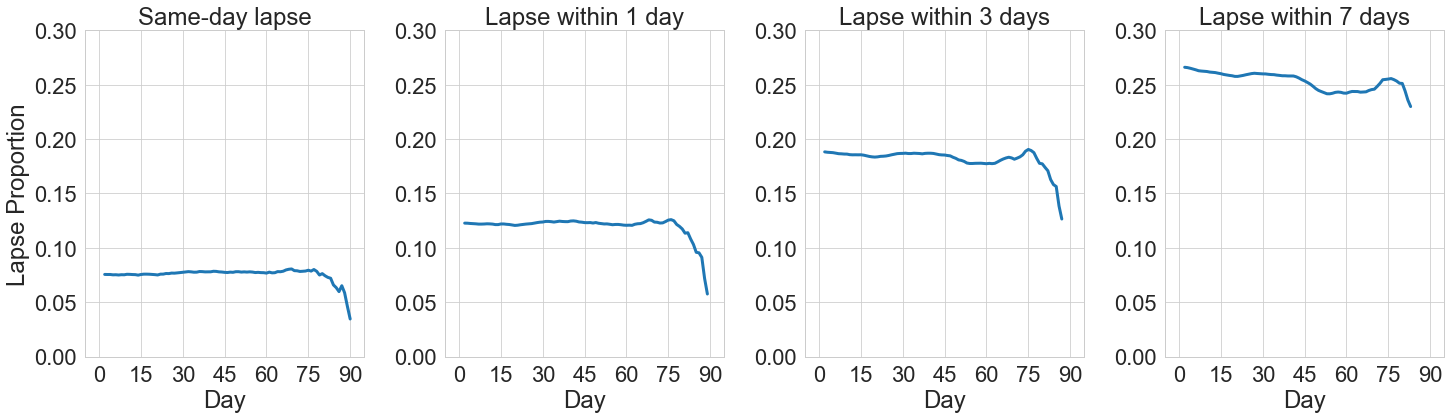

In [15]:
#hue_ord=['MAP_mle','MAP_marss','MLE','MARSS','LR','GB']
#hue_ord=['MAP','MLE','LR','XGB']
eval_df.replace(to_replace='MAP',value='SSM',inplace=True)
#ue_ord=['SSM','LR','XGB']
#hue_ord=['XGB']
pane_titles = ['Same-day lapse', 'Lapse within 1 day', 'Lapse within 3 days','Lapse within 7 days']
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2.5)
fig = plt.figure(figsize=(20,6))
subfigs = fig.subfigures(1,4,wspace=0.05)
for i,delta in enumerate(window_delta):
    ax = subfigs[i].subplots()
    nan_val = np.nan
    #sns.pointplot(data=eval_df.query("window==@delta"),x='horizon',y='auc',hue='fit_type',ax=ax,native_scale=True)
    sns.lineplot(data=eval_df.query("lapse_prop!=@nan_val & window==@delta"),x='day',y='lapse_prop',linewidth=3,ax=ax)#,native_scale=True)
    ax.set_title(pane_titles[i])
    ax.set_xlim(-5,95)
    ax.set_ylim(0,0.3)
    #ax.set_yticks(np.arange(0.8,1.04,0.04))
    ax.set_xticks(np.arange(0,105,15))
    ax.set_xlabel('Day')
    if i==0:
        ax.set_ylabel('Lapse Proportion')
    else:
        ax.set_ylabel('')

#fig.suptitle('AUC by time step for different prediction windows')
#fig.tight_layout()
#fig.savefig("plots/paper_plots/ss_ml_auc_prospective.pdf",bbox_inches='tight',facecolor='w')

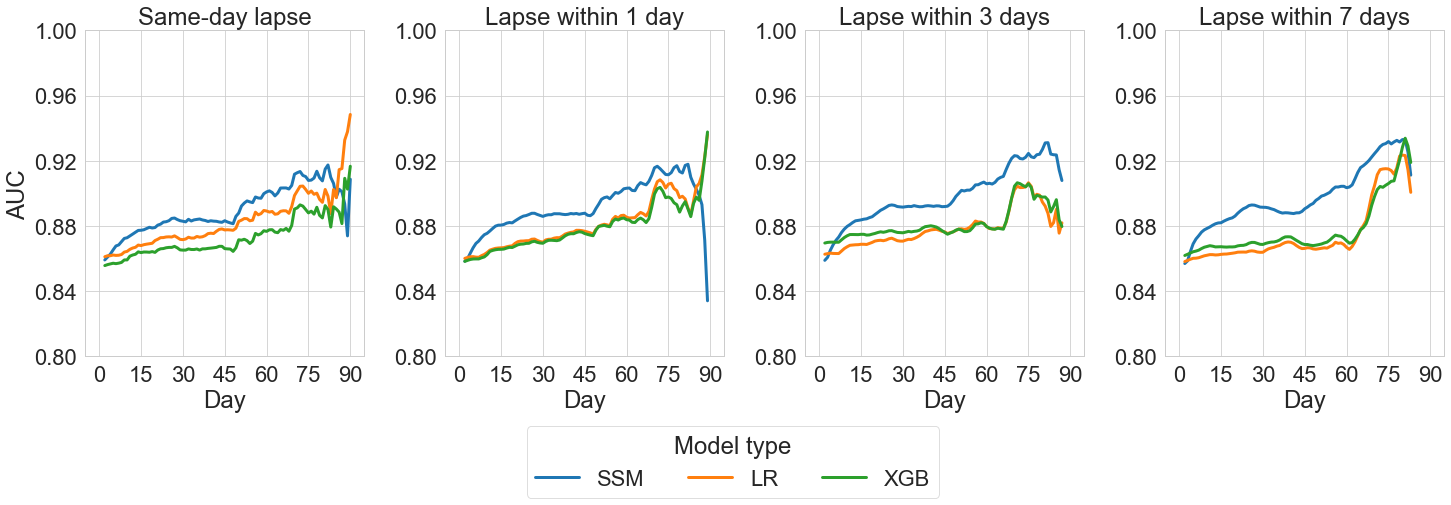

In [17]:
#hue_ord=['MAP_mle','MAP_marss','MLE','MARSS','LR','GB']
#hue_ord=['MAP','MLE','LR','XGB']
eval_df.replace(to_replace='MAP',value='SSM',inplace=True)
hue_ord=['SSM','LR','XGB']
#hue_ord=['XGB']
pane_titles = ['Same-day lapse', 'Lapse within 1 day', 'Lapse within 3 days','Lapse within 7 days']
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2.5)
fig = plt.figure(figsize=(20,6))
subfigs = fig.subfigures(1,4,wspace=0.05)
for i,delta in enumerate(window_delta):
    ax = subfigs[i].subplots()
    #sns.pointplot(data=eval_df.query("window==@delta"),x='horizon',y='auc',hue='fit_type',ax=ax,native_scale=True)
    sns.lineplot(data=eval_df.query("fit_type in @hue_ord & window==@delta"),x='day',y='auc',hue='fit_type',linewidth=3,hue_order=hue_ord,ax=ax)#,native_scale=True)
    ax.set_title(pane_titles[i])
    ax.set_xlim(-5,95)
    ax.set_ylim(.8,1.0)
    ax.set_yticks(np.arange(0.8,1.04,0.04))
    ax.set_xticks(np.arange(0,105,15))
    ax.set_xlabel('Day')
    if i==0:
        ax.set_ylabel('AUC')
    else:
        ax.set_ylabel('')
    if delta==7:
        ax.legend(title='Model type')
        #ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),title="Model type")
    else:
        ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()

plt.legend(handles=handles,ncol=4,loc='upper center',title='Model type',bbox_to_anchor=(-1.55,-0.18))
#fig.suptitle('AUC by time step for different prediction windows')
#fig.tight_layout()
fig.savefig("plots/paper_plots/ss_ml_auc_prospective.pdf",bbox_inches='tight',facecolor='w')

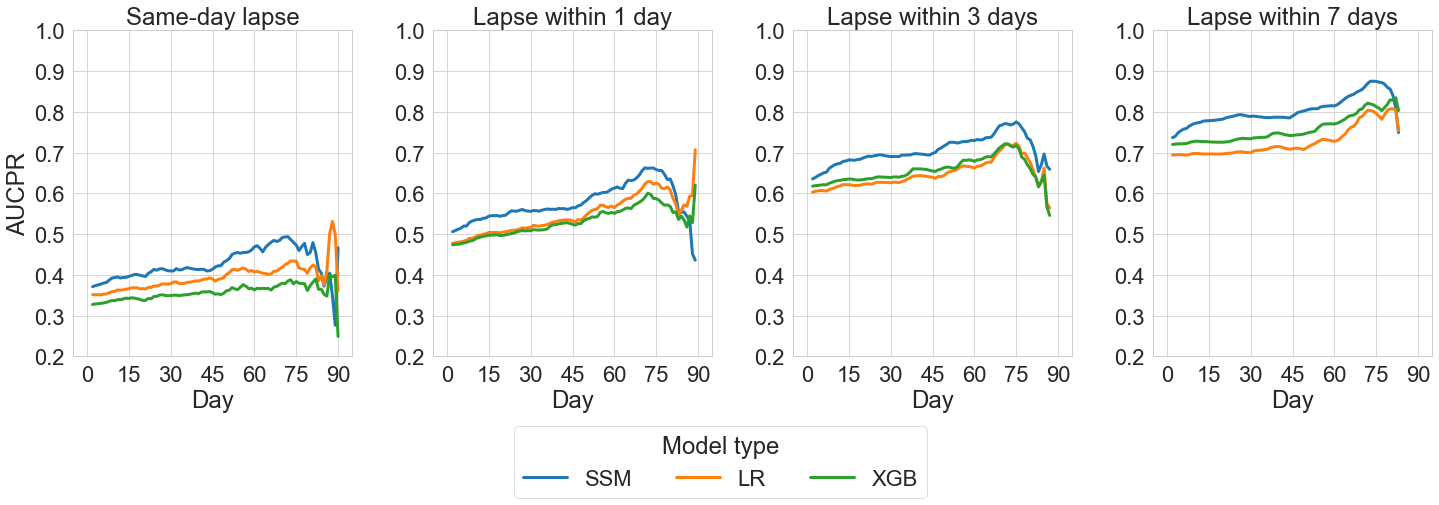

In [22]:
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2.5)
fig = plt.figure(figsize=(20,6))
subfigs = fig.subfigures(1,4,wspace=0.05)
for i,delta in enumerate(window_delta):
    ax = subfigs[i].subplots()
    #sns.pointplot(data=eval_df.query("window==@delta"),x='horizon',y='auc',hue='fit_type',ax=ax,native_scale=True)
    sns.lineplot(data=eval_df.query("fit_type in @hue_ord & window==@delta"),x='day',y='aucpr',hue='fit_type',linewidth=3,hue_order=hue_ord,ax=ax)#,native_scale=True)
    ax.set_title(pane_titles[i])
    ax.set_xlim(-5,95)
    ax.set_ylim(0.2,1.0)
    ax.set_yticks(np.arange(0.2,1.1,0.1))
    ax.set_xticks(np.arange(0,105,15))
    ax.set_xlabel('Day')
    if i==0:
        ax.set_ylabel('AUCPR')
    else:
        ax.set_ylabel('')
    if delta==7:
        ax.legend(title='Model type')
        #ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),title="Model type")
    else:
        ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()

plt.legend(handles=handles,ncol=4,loc='upper center',title='Model type',bbox_to_anchor=(-1.55,-0.18))
fig.savefig("plots/paper_plots/ss_ml_aucpr_prospective.pdf",bbox_inches='tight',facecolor='w')

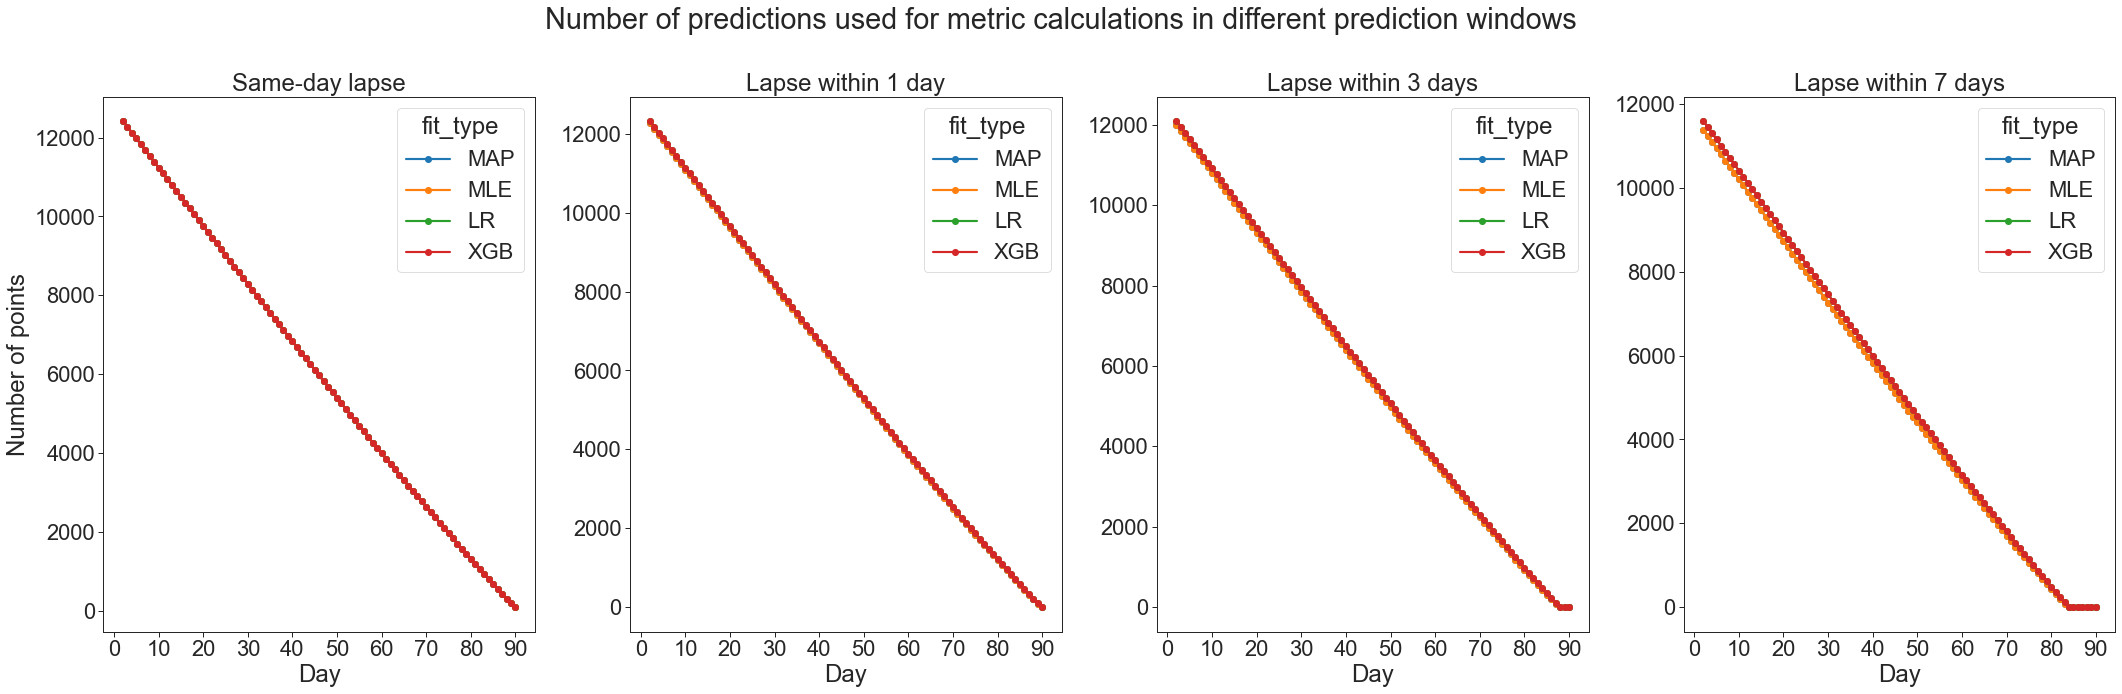

In [86]:
sns.set_style('ticks')
sns.set_context('paper',font_scale=2.5)
fig,axs = plt.subplots(1,4,figsize=(30,10))
for i,delta in enumerate(window_delta):
    #sns.pointplot(data=eval_df.query("window==@delta"),x='horizon',y='auc',hue='fit_type',ax=axs[i],native_scale=True)
    sns.pointplot(data=eval_df.query("window==@delta"),x='day',y='count',hue="fit_type",hue_order=hue_ord,ax=axs[i],native_scale=True)
    axs[i].set_title(pane_titles[i])
    #axs[i].set_xlim(-5,95)
    #axs[i].set_ylim(.7,1.0)
    #axs[i].set_yticks(np.arange(0.7,1.0,0.05))
    axs[i].set_xticks(np.arange(0,100,10))
    axs[i].set_xlabel('Day')
    if i==0:
        axs[i].set_ylabel('Number of points')
    else:
        axs[i].set_ylabel('')
    #axs[i].legend(title='Model type')
fig.suptitle('Number of predictions used for metric calculations in different prediction windows')
fig.tight_layout()
#fig.savefig("plots/ss_ml_point_count.pdf",bbox_inches='tight',facecolor='w')

In [11]:
full_df.head()

,subid,study_day,day,w0_pred,w0_act,w1_pred,w1_act,w3_pred,w3_act,w7_pred,w7_act,fit_type
0,224,2,2,2.942349e-02,0,5.964507e-02,0.0,1.115515e-01,0.0,1.872270e-01,0.0,MAP_mle
1,224,3,3,1.760611e-02,0,1.810747e-02,0.0,1.823019e-02,0.0,1.823113e-02,0.0,MAP_mle
2,224,4,4,9.999779e-13,0,4.726882e-07,0.0,4.726902e-07,0.0,4.726942e-07,0.0,MAP_mle
3,224,5,5,6.679497e-02,0,1.275270e-01,0.0,2.328210e-01,0.0,4.030883e-01,0.0,MAP_mle
4,224,6,6,1.004405e-02,0,1.088132e-02,0.0,1.309604e-02,0.0,1.510666e-02,0.0,MAP_mle


In [164]:
# 1690562 is the ML data efficiency run for 5foldCV (random state 1)
run = 1690562
new_format = run>1572467
import_path = "/Users/eric/repos/aud/analysis/imports/"+str(run)

files = [file for file in os.listdir(import_path) if file.endswith(".csv")]
df_list = []
for file in files:
    iter_df = pd.read_csv(os.path.join(import_path,file))
    df_list.append(iter_df)

#print(len(df_list))
ml_df = pd.concat(df_list,ignore_index=True)
print(ml_df.shape)
# The ML fits are done on zero-indexed data, need to add 1 to get to 1 indexing
ml_df.day = ml_df.day+1

def ml_fit_study_day_adder(subid,day,subject_info):
    sub = subject_info.query("subid==@subid")
    first_ema = sub.iloc[0].first_morning_ema_day # note 0 indexed
    if first_ema == 0:
        return int(day)
    else:
        return int(day-first_ema)

ml_df['study_day'] = ml_df.apply(lambda row: ml_fit_study_day_adder(row.subid,row.day,subject_info),axis=1)
ml_df.head()
# if not(new_format):
#     ml_df.insert(loc=1, column = 'train_horizon',value = np.nan)
# ml_df.head()

# if new_format:
#     full_df = ss_df.reset_index(drop=True)
# else:
#     full_df = pd.concat([ss_df,ml_df],ignore_index=True)
full_df.head()

(486506, 8)


,subid,study_day,day,w0_pred,w0_act,w1_pred,w1_act,w3_pred,w3_act,w7_pred,w7_act,fit_type
0,224,2,2,2.942349e-02,0,5.964507e-02,0.0,1.115515e-01,0.0,1.872270e-01,0.0,MAP_mle
1,224,3,3,1.760611e-02,0,1.810747e-02,0.0,1.823019e-02,0.0,1.823113e-02,0.0,MAP_mle
2,224,4,4,9.999779e-13,0,4.726882e-07,0.0,4.726902e-07,0.0,4.726942e-07,0.0,MAP_mle
3,224,5,5,6.679497e-02,0,1.275270e-01,0.0,2.328210e-01,0.0,4.030883e-01,0.0,MAP_mle
4,224,6,6,1.004405e-02,0,1.088132e-02,0.0,1.309604e-02,0.0,1.510666e-02,0.0,MAP_mle


In [167]:
ml_df.head()

,subid,day,train_width,key,window,pred,act,fit_type,study_day
0,2,1,15,split5_rs1_fold2_id0,0,0.015613,0.0,LR,1
1,2,2,15,split5_rs1_fold2_id0,0,0.026548,0.0,LR,2
2,2,3,15,split5_rs1_fold2_id0,0,0.017678,0.0,LR,3
3,2,4,15,split5_rs1_fold2_id0,0,0.010461,0.0,LR,4
4,2,5,15,split5_rs1_fold2_id0,0,0.016802,0.0,LR,5


In [ ]:
ml_df.query("study_day<train_width").head()

In [16]:
# Rolling plots
# 1581009 gives the full array of training values for a small subset of subjects
# 1582199 gives the 5-step array of rolling evaluations for a small subset of subjects
# 1582295 gives the 5-step array of rolling evaluations for the complete subset of individuals
# 1582295_1582732 combines the MAP and MLE runs for 5-step rolling evaluations of all individuals
# 1586147 gives the MAP runs for 5-step rolling evaluations of all individuals, with updated lapse labeling
# 1690561 gives the MAP runs for 15-step rolling evaluation sof all individuals using 5fold CV (random state 1)
import_path = "/Users/eric/repos/aud/analysis/imports/1586147"

files = [file for file in os.listdir(import_path) if file.endswith(".csv")]
df_list = []
for file in files:
    iter_df = pd.read_csv(os.path.join(import_path,file))
    if iter_df.shape[1] != 23:
        pass#print("wtf")
    df_list.append(iter_df)

#print(len(df_list))
df = pd.concat(df_list,ignore_index=True)
print(df.shape)
df.head()


rolling_df = df[['subid','train_width','day','w0_pred','w0_act','w1_pred',
                  'w1_act','w3_pred','w3_act','w7_pred','w7_act','fit_type']].rename(mapper={'day':'end_day'},axis=1)

rolling_df.head()

(105348, 24)


,subid,train_width,end_day,w0_pred,w0_act,w1_pred,w1_act,w3_pred,w3_act,w7_pred,w7_act,fit_type
0,116,5,5,0.464950,1,0.753937,1.0,0.972214,1.0,0.999997,1.0,MAP_mle
1,116,5,6,0.498394,1,0.800577,1.0,0.984084,1.0,0.999999,1.0,MAP_mle
2,116,5,7,0.553172,0,0.825646,0.0,0.983492,0.0,0.999991,0.0,MAP_mle
3,116,5,8,0.240078,0,0.414511,0.0,0.622395,0.0,0.786715,0.0,MAP_mle
4,116,5,9,0.222232,0,0.400943,0.0,0.653798,0.0,0.895797,0.0,MAP_mle


In [17]:
widths = rolling_df.train_width.unique()
eval_df_list = []
window_delta = [0,1,3,7]

for delta in window_delta:
    delta_str = "w"+str(delta)
    for width in widths:
        print(width)
        iter_df = rolling_df.query("train_width==@width").copy(deep=True)
        for fit_type in ['MAP_mle']:#['MAP_mle','MLE']:
            sub_df = iter_df.query("fit_type==@fit_type")
            pred_str = delta_str+'_pred'
            act_str = delta_str+'_act'
            pred = sub_df[pred_str].dropna().to_numpy()
            act = sub_df[act_str].dropna().to_numpy()
            if fit_type=='MAP_mle':
                print("{} {} {} {}".format(str(width), str(delta), str(fit_type),str(len(act))))
            if len(pred)==0:
                auc = np.nan
                aucpr = np.nan
                count = 0
            else:
                # no positive class check
                if sum(act)==0:
                    auc = np.nan
                    aucpr = np.nan
                    count = 0
                else:
                    auc = roc_auc_score(act,pred)
                    aucpr = average_precision_score(act,pred)
                    count = len(pred)
            eval_iter_df = pd.DataFrame({"width":width,"fit_type":fit_type,"auc":auc,"aucpr":aucpr,"window":delta,"count":count},index=[0])
            #eval_iter_df = pd.DataFrame({"day":day,"fit_type":fit_type,"auc":auc,"aucpr":aucpr,"window":delta},index=[0])
            eval_df_list.append(eval_iter_df)

rolling_eval_df = pd.concat(eval_df_list,ignore_index=True)
rolling_eval_df.replace(to_replace='MAP_mle',value='SSM',inplace=True)
rolling_eval_df.head()

5
5 0 MAP_mle 11981
10
10 0 MAP_mle 11241
15
15 0 MAP_mle 10501
20
20 0 MAP_mle 9761
25
25 0 MAP_mle 9023
30
30 0 MAP_mle 8288
35
35 0 MAP_mle 7553
40
40 0 MAP_mle 6829
45
45 0 MAP_mle 6111
50
50 0 MAP_mle 5397
55
55 0 MAP_mle 4687
60
60 0 MAP_mle 3989
65
65 0 MAP_mle 3309
70
70 0 MAP_mle 2634
75
75 0 MAP_mle 1966
80
80 0 MAP_mle 1312
85
85 0 MAP_mle 679
90
90 0 MAP_mle 87
5
5 1 MAP_mle 11833
10
10 1 MAP_mle 11093
15
15 1 MAP_mle 10353
20
20 1 MAP_mle 9613
25
25 1 MAP_mle 8876
30
30 1 MAP_mle 8141
35
35 1 MAP_mle 7408
40
40 1 MAP_mle 6685
45
45 1 MAP_mle 5968
50
50 1 MAP_mle 5255
55
55 1 MAP_mle 4546
60
60 1 MAP_mle 3853
65
65 1 MAP_mle 3174
70
70 1 MAP_mle 2499
75
75 1 MAP_mle 1833
80
80 1 MAP_mle 1185
85
85 1 MAP_mle 553
90
90 1 MAP_mle 0
5
5 3 MAP_mle 11537
10
10 3 MAP_mle 10797
15
15 3 MAP_mle 10057
20
20 3 MAP_mle 9317
25
25 3 MAP_mle 8582
30
30 3 MAP_mle 7847
35
35 3 MAP_mle 7118
40
40 3 MAP_mle 6397
45
45 3 MAP_mle 5682
50
50 3 MAP_mle 4971
55
55 3 MAP_mle 4264
60
60 3 MAP_mle 3

,width,fit_type,auc,aucpr,window,count
0,5,SSM,0.800159,0.323341,0,11981
1,10,SSM,0.846176,0.392472,0,11241
2,15,SSM,0.867843,0.396126,0,10501
3,20,SSM,0.871827,0.395445,0,9761
4,25,SSM,0.876914,0.406408,0,9023


In [21]:
eval_df.head()

,day,fit_type,auc,aucpr,ba,window,count,lapse_prop
0,2,LR,0.861159,0.351565,0.789575,0,12424,NaN
1,2,XGB,0.855735,0.327489,0.779400,0,12424,NaN
2,3,LR,0.861760,0.351470,0.790820,0,12276,NaN
3,3,XGB,0.856325,0.328697,0.780135,0,12276,NaN
4,4,LR,0.861790,0.351628,0.791154,0,12128,NaN


In [39]:
rolling_eval_df.head()

,width,fit_type,auc,aucpr,window,count
0,5,SSM,0.800159,0.323341,0,11981
1,10,SSM,0.846176,0.392472,0,11241
2,15,SSM,0.867843,0.396126,0,10501
3,20,SSM,0.871827,0.395445,0,9761
4,25,SSM,0.876914,0.406408,0,9023


In [22]:
ml_mods = ['LR','XGB']
type = 'prosp'
mod_eval_df = eval_df.query("fit_type in @ml_mods").copy(deep=True).drop(columns=['ba','lapse_prop'])

if new_format:
    if type=='avg':
        for delta in window_delta:
            for fit_type in ml_mods:
                sub_df = ml_df.query("fit_type==@fit_type & window==@delta")
                pred = sub_df["pred"].dropna().to_numpy()
                act = sub_df["act"].dropna().to_numpy()
                max_day = ml_df.dropna(axis=0,subset='pred').study_day.max()
                if len(pred)==0:
                    auc = np.nan
                    aucpr = np.nan
                    count = 0
                else:
                    # no positive class check
                    if sum(act)==0:
                        auc = np.nan
                        aucpr = np.nan
                        count = 0
                    else:
                        auc = roc_auc_score(act,pred)
                        aucpr = average_precision_score(act,pred)
                        count = len(pred)
                #mod_eval_df.query("fit_type==@fit_type & window==@delta")["auc"] = auc
                #mod_eval_df.query("fit_type==@fit_type & window==@delta")["aucpr"] = aucpr
                row_idx  = (mod_eval_df.fit_type==fit_type) & (mod_eval_df.window==delta) & (mod_eval_df.day<=max_day)
                mod_eval_df.loc[row_idx,"auc"]=auc
                mod_eval_df.loc[row_idx,"aucpr"]=aucpr
    elif type=='prosp':
        mod_eval_df =  mod_eval_df.query("day in @widths").copy(deep=True)
    else:
        print("Script case not written")
else:
    print("Script case not written")
mod_eval_df.rename(mapper={'day':'width'},axis=1,inplace=True)
#mod_eval_df.head()

mod_rolling_df = pd.concat([rolling_eval_df,mod_eval_df],ignore_index=True)
mod_rolling_df.head()

,width,fit_type,auc,aucpr,window,count
0,5,SSM,0.800159,0.323341,0,11981
1,10,SSM,0.846176,0.392472,0,11241
2,15,SSM,0.867843,0.396126,0,10501
3,20,SSM,0.871827,0.395445,0,9761
4,25,SSM,0.876914,0.406408,0,9023


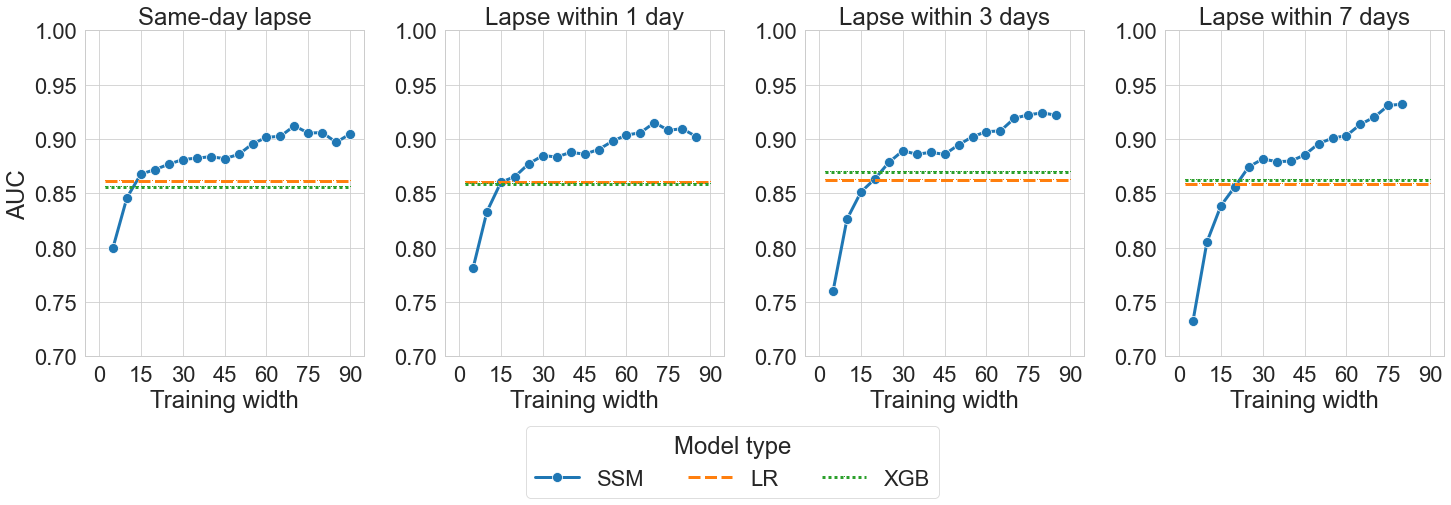

In [123]:
#hue_ord=['MAP_mle','MAP_marss','MLE','MARSS','LR','GB']
hue_ord=['SSM','LR','XGB']
ml_linestyle =  [(1,1),(2,2)]#{"LR":"dashed","XGB":"dotted"}
#hue_ord=['XGB']
pane_titles = ['Same-day lapse', 'Lapse within 1 day', 'Lapse within 3 days','Lapse within 7 days']
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2.5)
fig = plt.figure(figsize=(20,6))
subfigs = fig.subfigures(1,4,wspace=0.05)
limited_palette = sns.color_palette()[1:3]
for i,delta in enumerate(window_delta):
    ax = subfigs[i].subplots()
    #sns.pointplot(data=eval_df.query("window==@delta"),x='horizon',y='auc',hue='fit_type',ax=ax,native_scale=True)
    sns.lineplot(data=mod_rolling_df.query("fit_type in @hue_ord & window==@delta"),x='width',y='auc',hue='fit_type',style='fit_type',markersize=10,markers={'SSM':'o','LR':',','XGB':','},linewidth=3,hue_order=hue_ord,ax=ax)#,native_scale=True)
    handles, labels = ax.get_legend_handles_labels()
    #sns.lineplot(data=mod_rolling_df.query("fit_type in @ml_mods & window==@delta"),x='width',y='auc',hue='fit_type',style='fit_type',linewidth=2,hue_order=ml_mods,ax=ax,palette=limited_palette,dashes=ml_linestyle)
    ax.set_title(pane_titles[i])
    ax.set_xlim(-5,95)
    ax.set_ylim(0.7,1.0)
    #ax.set_yticks(np.arange(0.8,1.04,0.04))
    ax.set_xticks(np.arange(0,105,15))
    ax.set_xlabel('Training width')
    if i==0:
        ax.set_ylabel('AUC')
    else:
        ax.set_ylabel('')
    if delta==7:
        ax.legend(title='Model type')
        #ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),title="Model type")
    else:
        ax.get_legend().remove()
#handles, labels = ax.get_legend_handles_labels()

plt.legend(handles=handles,ncol=4,loc='upper center',title='Model type',bbox_to_anchor=(-1.55,-0.18))
#fig.suptitle('AUC by time step for different prediction windows')
#fig.tight_layout()
#fig.savefig("plots/paper_plots/ss_ml_auc_rolling.png",bbox_inches='tight',facecolor='w')

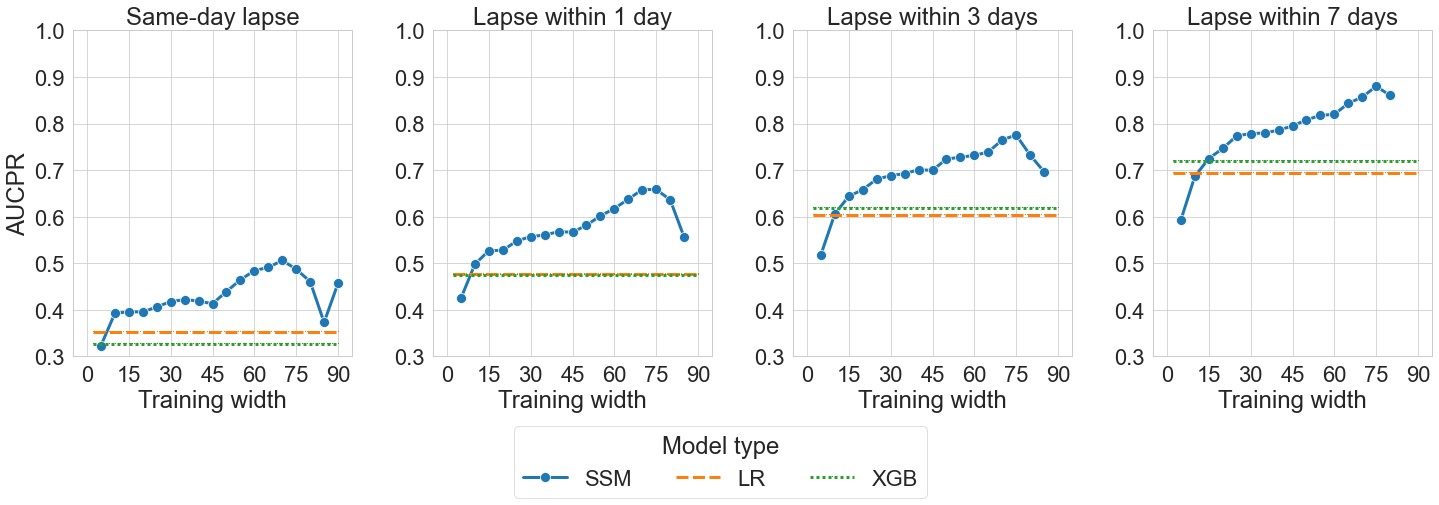

In [129]:
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2.5)
fig = plt.figure(figsize=(20,6))
subfigs = fig.subfigures(1,4,wspace=0.05)
for i,delta in enumerate(window_delta):
    ax = subfigs[i].subplots()
    #sns.pointplot(data=eval_df.query("window==@delta"),x='horizon',y='auc',hue='fit_type',ax=ax,native_scale=True)
    sns.lineplot(data=mod_rolling_df.query("fit_type in @hue_ord & window==@delta"),x='width',y='aucpr',hue='fit_type',style='fit_type',markersize=10,markers={'SSM':'o','LR':',','XGB':','},linewidth=3,hue_order=hue_ord,ax=ax)#,native_scale=True)
    handles, labels = ax.get_legend_handles_labels()
    #sns.lineplot(data=mod_rolling_df.query("fit_type in @ml_mods & window==@delta"),x='width',y='aucpr',hue='fit_type',linewidth=3,hue_order=ml_mods,ax=ax,palette=limited_palette)
    ax.set_title(pane_titles[i])
    ax.set_xlim(-5,95)
    ax.set_ylim(0.3,1.0)
    ax.set_yticks(np.arange(0.3,1.1,0.1))
    ax.set_xticks(np.arange(0,105,15))
    ax.set_xlabel('Training width')
    if i==0:
        ax.set_ylabel('AUCPR')
    else:
        ax.set_ylabel('')
    if delta==7:
        ax.legend(title='Model type')
        #ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),title="Model type")
    else:
        ax.get_legend().remove()
#handles, labels = ax.get_legend_handles_labels()

plt.legend(handles=handles,ncol=4,loc='upper center',title='Model type',bbox_to_anchor=(-1.55,-0.18))
#fig.suptitle('AUC by time step for different prediction windows')
#fig.tight_layout()
fig.savefig("plots/paper_plots/ss_ml_aucpr_rolling.png",bbox_inches='tight',facecolor='w')

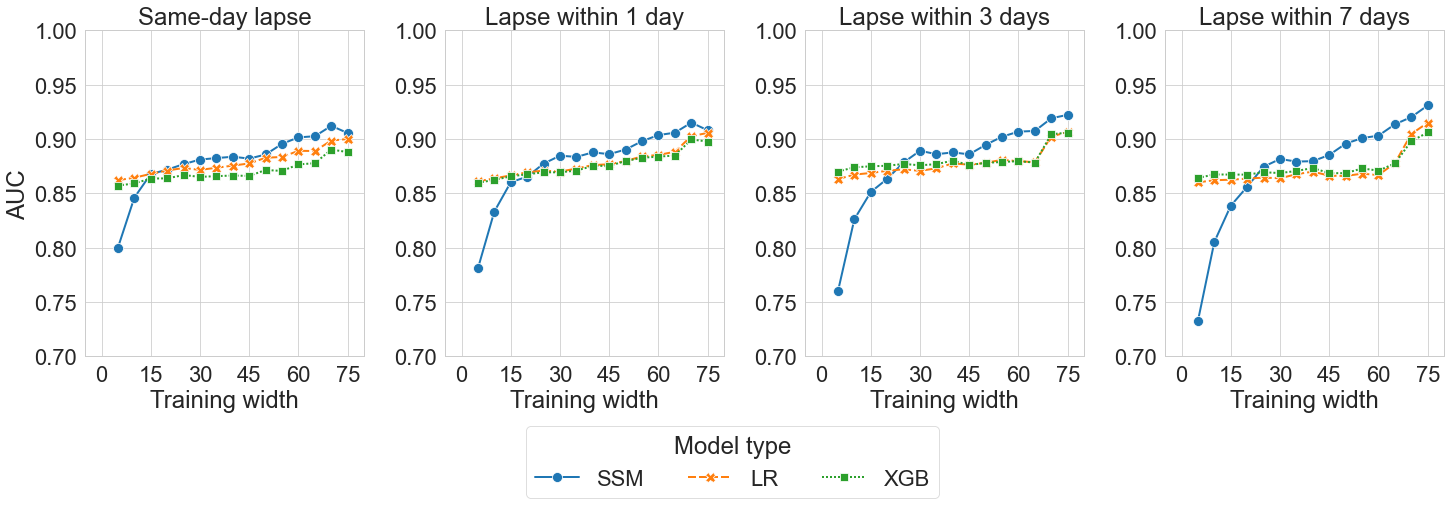

In [29]:
# Prospective version
hue_ord=['SSM','LR','XGB']
#ml_linestyle =  [(1,1),(2,2)]#{"LR":"dashed","XGB":"dotted"}
#hue_ord=['XGB']
pane_titles = ['Same-day lapse', 'Lapse within 1 day', 'Lapse within 3 days','Lapse within 7 days']
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2.5)
fig = plt.figure(figsize=(20,6))
subfigs = fig.subfigures(1,4,wspace=0.05)
limited_palette = sns.color_palette()[1:3]
for i,delta in enumerate(window_delta):
    ax = subfigs[i].subplots()
    #sns.pointplot(data=eval_df.query("window==@delta"),x='horizon',y='auc',hue='fit_type',ax=ax,native_scale=True)
    sns.lineplot(data=mod_rolling_df.query("fit_type in @hue_ord & window==@delta & width <=75"),x='width',y='auc',hue='fit_type',style='fit_type',markersize=10,markers = True,linewidth=2,hue_order=hue_ord,ax=ax)#,native_scale=True)
    handles, labels = ax.get_legend_handles_labels()
    #sns.lineplot(data=mod_rolling_df.query("fit_type in @ml_mods & window==@delta"),x='width',y='auc',hue='fit_type',style='fit_type',linewidth=2,hue_order=ml_mods,ax=ax,palette=limited_palette,dashes=ml_linestyle)
    ax.set_title(pane_titles[i])
    ax.set_xlim(-5,80)
    ax.set_ylim(0.7,1.0)
    #ax.set_yticks(np.arange(0.8,1.04,0.04))
    ax.set_xticks(np.arange(0,90,15))
    ax.set_xlabel('Training width')
    if i==0:
        ax.set_ylabel('AUC')
    else:
        ax.set_ylabel('')
    if delta==7:
        ax.legend(title='Model type')
        #ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),title="Model type")
    else:
        ax.get_legend().remove()
#handles, labels = ax.get_legend_handles_labels()

plt.legend(handles=handles,ncol=4,loc='upper center',title='Model type',bbox_to_anchor=(-1.55,-0.18))
#fig.suptitle('AUC by time step for different prediction windows')
#fig.tight_layout()
fig.savefig("plots/paper_plots/ss_ml_auc_rolling_prosp.pdf",bbox_inches='tight',facecolor='w')

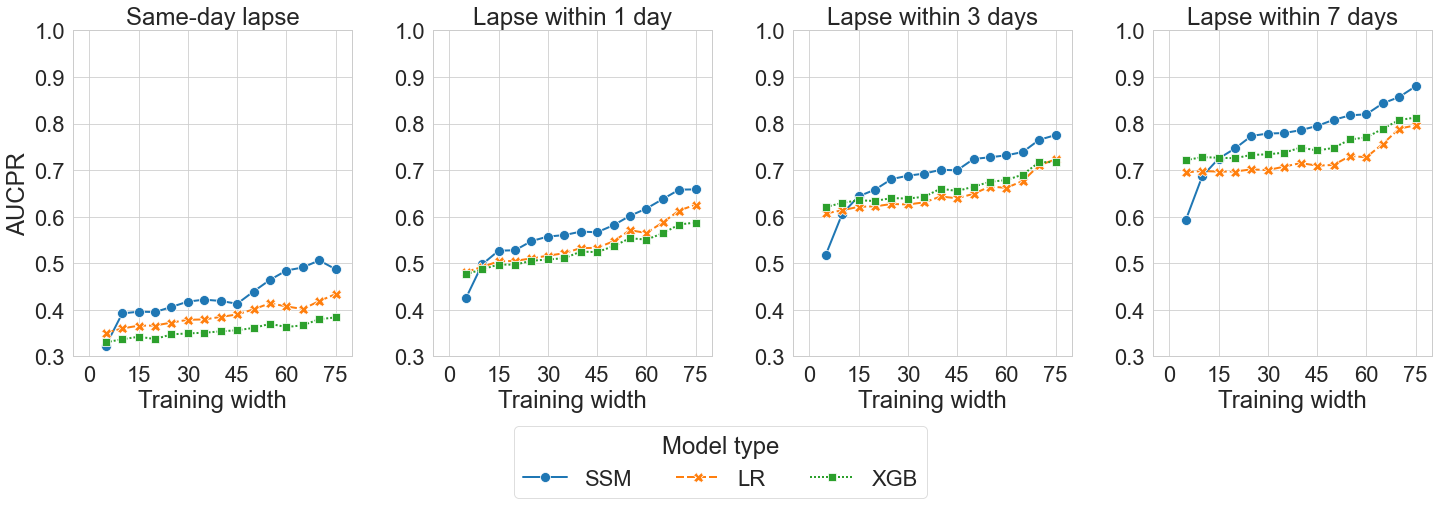

In [31]:
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2.5)
fig = plt.figure(figsize=(20,6))
subfigs = fig.subfigures(1,4,wspace=0.05)
for i,delta in enumerate(window_delta):
    ax = subfigs[i].subplots()
    #sns.pointplot(data=eval_df.query("window==@delta"),x='horizon',y='auc',hue='fit_type',ax=ax,native_scale=True)
    sns.lineplot(data=mod_rolling_df.query("fit_type in @hue_ord & window==@delta & width <=75"),x='width',y='aucpr',hue='fit_type',style='fit_type',markersize=10,markers=True,linewidth=2,hue_order=hue_ord,ax=ax)#,native_scale=True)
    handles, labels = ax.get_legend_handles_labels()
    #sns.lineplot(data=mod_rolling_df.query("fit_type in @ml_mods & window==@delta"),x='width',y='aucpr',hue='fit_type',linewidth=3,hue_order=ml_mods,ax=ax,palette=limited_palette)
    ax.set_title(pane_titles[i])
    ax.set_xlim(-5,80)
    ax.set_ylim(0.3,1.0)
    ax.set_yticks(np.arange(0.3,1.1,0.1))
    ax.set_xticks(np.arange(0,90,15))
    ax.set_xlabel('Training width')
    if i==0:
        ax.set_ylabel('AUCPR')
    else:
        ax.set_ylabel('')
    if delta==7:
        ax.legend(title='Model type')
        #ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),title="Model type")
    else:
        ax.get_legend().remove()
#handles, labels = ax.get_legend_handles_labels()

plt.legend(handles=handles,ncol=4,loc='upper center',title='Model type',bbox_to_anchor=(-1.55,-0.18))
#fig.suptitle('AUC by time step for different prediction windows')
#fig.tight_layout()
fig.savefig("plots/paper_plots/ss_ml_aucpr_rolling_prosp.png",bbox_inches='tight',facecolor='w')

In [41]:
from sklearn.model_selection import StratifiedGroupKFold

day_labels_path = "/Users/eric/repos/aud/data/day_labels.csv"
day_labels = pd.read_csv(day_labels_path)
day_labels.head()
testing_df = day_labels.query("subid in @included_subids").copy(deep=True).reset_index()[['subid','day','lapse']]
print(testing_df.shape)
testing_df.head()

(13320, 3)


,subid,day,lapse
0,1,0,0
1,1,1,0
2,1,2,0
3,1,3,0
4,1,4,0


In [156]:
sgkf = StratifiedGroupKFold(n_splits=4,shuffle=True)
X = testing_df[['subid','day']]
Y = testing_df[['lapse']]
groups = testing_df.subid
test_list = []
eval_groups = {}
for i,(train_index,test_index) in enumerate(sgkf.split(X,Y,groups=groups)):
    train_count = len(train_index)
    test_count = len(test_index)
    train_lapse = np.sum(Y.loc[train_index,"lapse"])
    train_prop = train_lapse/train_count
    test_lapse = np.sum(Y.loc[test_index,"lapse"])
    test_prop = test_lapse/test_count
    print("Fold {}, train count {}, test count {}, train_lapse {}, train lapse prop. {:.3f}, test_lapse {}, test lapse prop. {:.3f}"\
          .format(i,train_count,test_count,train_lapse,train_prop,test_lapse,test_prop))
    #print(X.loc[train_index].subid.unique())
    test_subids_iter = X.loc[test_index].subid.unique()
    print(test_subids_iter.tolist(),len(test_subids_iter))
    if any([val in test_list for val in test_subids_iter]):
        print("error!")
        break
    else:
        test_list.extend(test_subids_iter.tolist())
    eval_groups[i]=test_subids_iter

if len(test_list)!=len(included_subids):
    print("fatal error: missing subids")


Fold 0, train count 9900, test count 3420, train_lapse 570, train lapse prop. 0.058, test_lapse 387, test lapse prop. 0.113
[2, 10, 20, 29, 30, 31, 37, 44, 47, 48, 58, 63, 77, 86, 92, 103, 118, 128, 131, 139, 149, 158, 166, 180, 187, 191, 192, 200, 203, 212, 221, 222, 230, 238, 241, 243, 245, 264] 38
Fold 1, train count 9990, test count 3330, train_lapse 795, train lapse prop. 0.080, test_lapse 162, test lapse prop. 0.049
[3, 5, 15, 16, 25, 28, 32, 39, 51, 52, 53, 59, 78, 84, 85, 94, 97, 116, 134, 135, 143, 150, 167, 169, 183, 188, 197, 201, 209, 211, 213, 215, 223, 242, 248, 263, 270] 37
Fold 2, train count 9990, test count 3330, train_lapse 809, train lapse prop. 0.081, test_lapse 148, test lapse prop. 0.044
[1, 6, 9, 18, 19, 23, 27, 33, 40, 56, 65, 76, 82, 88, 93, 98, 99, 100, 109, 119, 136, 138, 156, 163, 171, 172, 178, 189, 190, 207, 218, 224, 240, 252, 255, 259, 265] 37
Fold 3, train count 10080, test count 3240, train_lapse 697, train lapse prop. 0.069, test_lapse 260, test laps